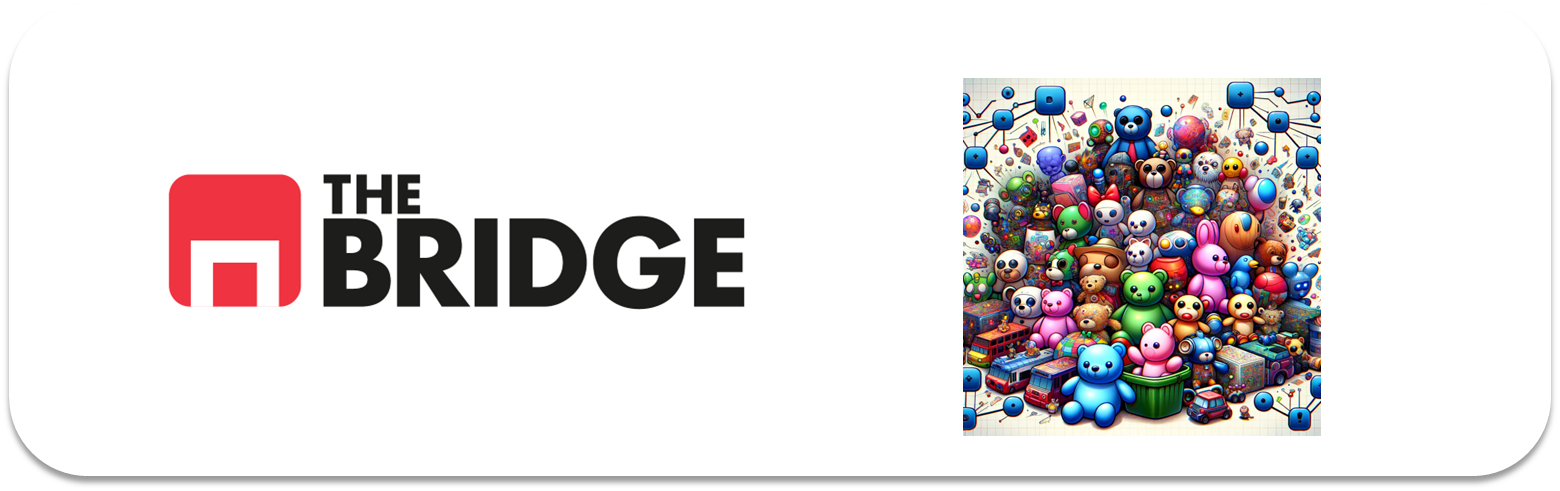

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


#### 2. Cargar datos, visualilzar.

In [14]:
df = pd.read_csv(r'C:\Users\pc\Documents\GitHub\Marzo 2026 Ana Belén\DS-Online-Ana-Belen-Escobar\04_Machine_Learning\Sprint_13\Unidad_02_ML_No_Supervisado_Clustering_DBSCAN\03_Practica_Obligatoria\data\empowering_drinks.csv', sep='|')
print('Shape:', df.shape)
df.head()

Shape: (153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [15]:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [16]:
print('Nulos por columna:')
print(df.isnull().sum())

Nulos por columna:
Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


#### 3. Mini-EDA: Visualización y selección de features

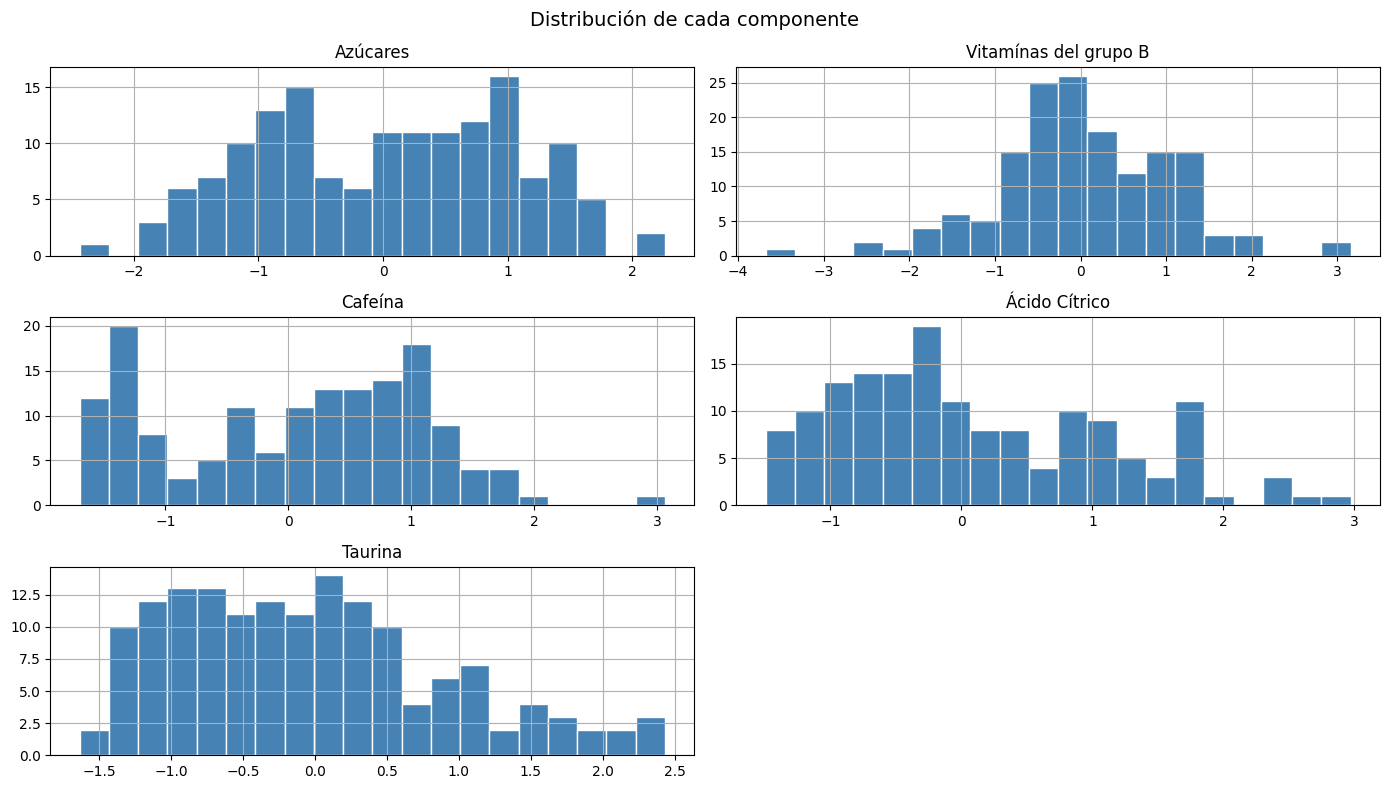

In [17]:
#Histogramas de cada variable
df.hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribución de cada componente', fontsize=14)
plt.tight_layout()
plt.show()

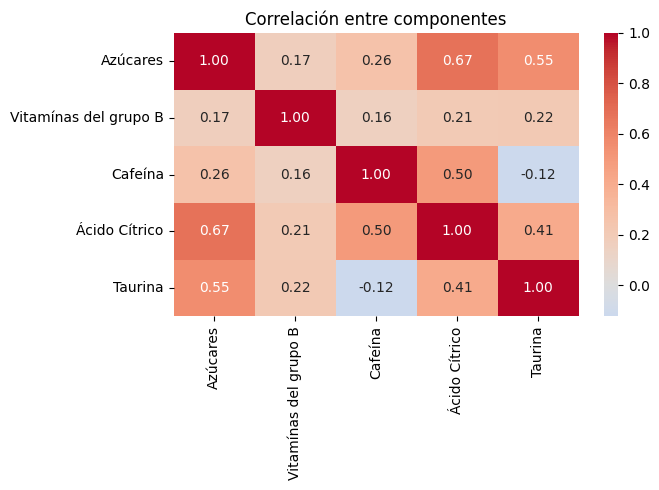

In [18]:
#Matriz de correlación
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre componentes')
plt.tight_layout()
plt.show()

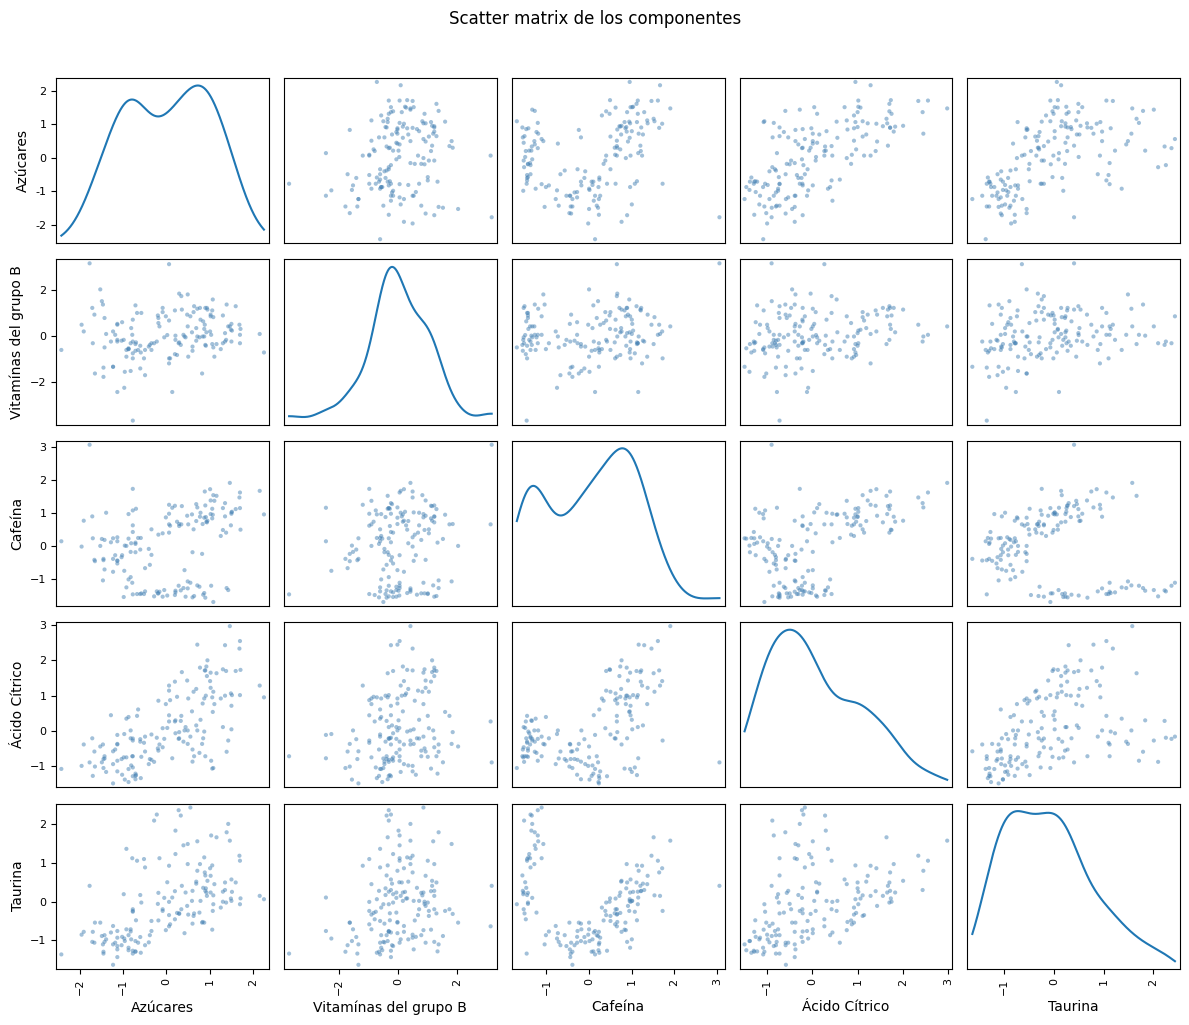

In [19]:
#Scatter matrix — visualizar features dos a dos
pd.plotting.scatter_matrix(df, figsize=(12, 10), alpha=0.5,
                           diagonal='kde', c='steelblue')
plt.suptitle('Scatter matrix de los componentes', y=1.02)
plt.tight_layout()
plt.show()

**Conclusión del EDA:**  
- Los datos ya están estandarizados (media ≈ 0, std ≈ 1).  
- No hay nulos.  
- Las correlaciones entre componentes son bajas, por lo que usaremos **todas las features** (ninguna aporta información redundante).
- La escala ya es homogénea → no hace falta volver a escalar.

#### 4. Tratamiento de features

In [20]:
#Los datos ya están escalados; los guardamos directamente como array
X = df.values
print('Shape de X:', X.shape)

Shape de X: (153, 5)


### 5 y 6 — Modelo 1: DBSCAN

#### Selección de hiperparámetros

El hiperparámetro clave de DBSCAN es `epsilon` (radio de vecindad). El método estándar para elegirlo es el **gráfico k-distancias**: se ordena la distancia al vecino k-ésimo de cada punto y se busca el "codo".

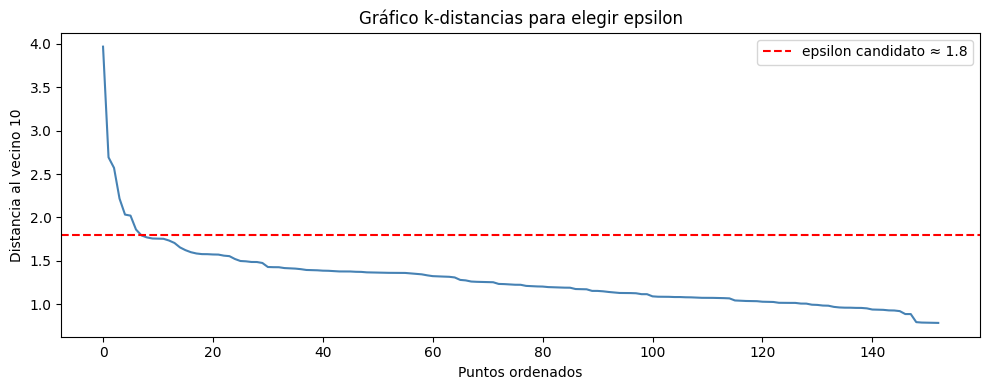

El "codo" del gráfico k-distancias sugiere un epsilon en torno a 1.8.


In [21]:
#Gráfico k-distancias para elegir epsilon
# min_samples suele fijarse como 2*n_features --> 2*5 = 10
min_samples = 10

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, min_samples - 1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='steelblue')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {min_samples}')
plt.title('Gráfico k-distancias para elegir epsilon')
plt.axhline(y=1.8, color='red', linestyle='--', label='epsilon candidato ≈ 1.8')
plt.legend()
plt.tight_layout()
plt.show()

print('El "codo" del gráfico k-distancias sugiere un epsilon en torno a 1.8.')

In [22]:
#Exploración de epsilon y min_samples para obtener entre 3 y 5 clústeres
print(f"{'epsilon':>8} {'min_s':>6} {'clústers':>10} {'ruido':>7} {'silhouette':>12}")
print('-' * 50)

for eps in [1.4, 1.6, 1.8, 2.0, 2.2]:
    for ms in [5, 8, 10]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask]) if mask.sum() > 1 else np.nan
        else:
            sil = np.nan
        print(f"{eps:>8.1f} {ms:>6d} {n_clusters:>10d} {n_noise:>7d} {sil:>12.4f}")

 epsilon  min_s   clústers   ruido   silhouette
--------------------------------------------------
     1.4      5          1       4          nan
     1.4      8          1       5          nan
     1.4     10          1       7          nan
     1.6      5          1       3          nan
     1.6      8          1       3          nan
     1.6     10          1       3          nan
     1.8      5          1       2          nan
     1.8      8          1       2          nan
     1.8     10          1       2          nan
     2.0      5          1       1          nan
     2.0      8          1       1          nan
     2.0     10          1       1          nan
     2.2      5          1       1          nan
     2.2      8          1       1          nan
     2.2     10          1       1          nan


In [23]:
#Modelo DBSCAN elegido: búsqueda automática del mejor epsilon y min_samples
# que de entre 3 y 5 clústeres con mejor silhouette y poco ruido

best_params = None
best_sil    = -1

for eps in np.arange(0.5, 2.5, 0.1):
    for ms in [3, 5, 8, 10]:
        db_tmp  = DBSCAN(eps=round(eps, 2), min_samples=ms)
        lbl_tmp = db_tmp.fit_predict(X)
        n_cl    = len(set(lbl_tmp)) - (1 if -1 in lbl_tmp else 0)
        n_noise = (lbl_tmp == -1).sum()

        if 3 <= n_cl <= 5:
            mask_tmp = lbl_tmp != -1
            sil = silhouette_score(X[mask_tmp], lbl_tmp[mask_tmp])
            if sil > best_sil:
                best_sil    = sil
                best_params = (round(eps, 2), ms, n_cl, n_noise)

BEST_EPS, BEST_MS, n_clusters_db, n_noise_db = best_params
print(f'Mejor configuración encontrada:')
print(f'  eps={BEST_EPS}, min_samples={BEST_MS}')
print(f'  Clústeres: {n_clusters_db}')
print(f'  Ruido:     {n_noise_db}')
print(f'  Silhouette Score (sin ruido): {best_sil:.4f}')

dbscan    = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS)
labels_db = dbscan.fit_predict(X)
print(f'\nDistribución: {pd.Series(labels_db).value_counts().to_dict()}')

Mejor configuración encontrada:
  eps=0.7, min_samples=5
  Clústeres: 3
  Ruido:     122
  Silhouette Score (sin ruido): 0.6148

Distribución: {-1: 122, 2: 16, 1: 10, 0: 5}


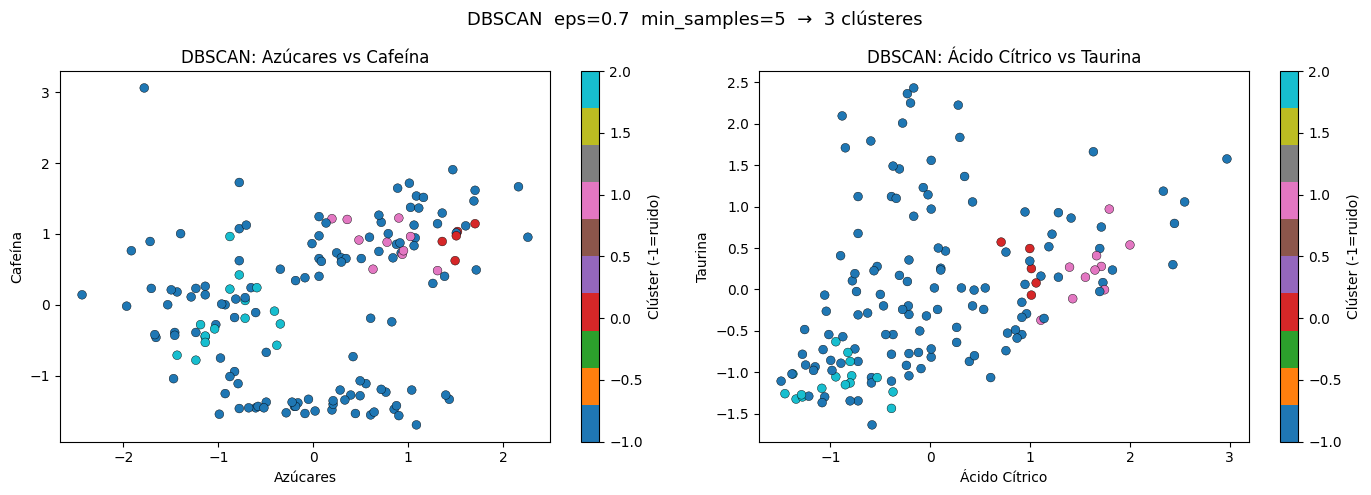

In [24]:
#Visualización DBSCAN en 2 pares de features representativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = df.columns.tolist()

pairs = [(0, 2), (3, 4)]   #(Azúcares vs Cafeína) y (Ácido Cítrico vs Taurina)
for ax, (i, j) in zip(axes, pairs):
    scatter = ax.scatter(X[:, i], X[:, j], c=labels_db,
                         cmap='tab10', s=40, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(cols[i])
    ax.set_ylabel(cols[j])
    ax.set_title(f'DBSCAN: {cols[i]} vs {cols[j]}')
    plt.colorbar(scatter, ax=ax, label='Clúster (-1=ruido)')

plt.suptitle(f'DBSCAN  eps={BEST_EPS}  min_samples={BEST_MS}  →  {n_clusters_db} clústeres', fontsize=13)
plt.tight_layout()
plt.show()

### Modelo 2: Clustering Jerárquico Aglomerativo

El enunciado pide poder *"establecer algún tipo de relación entre las segmentaciones"* → el **clustering jerárquico** es la elección natural porque el dendrograma muestra visualmente qué grupos son más similares entre sí.

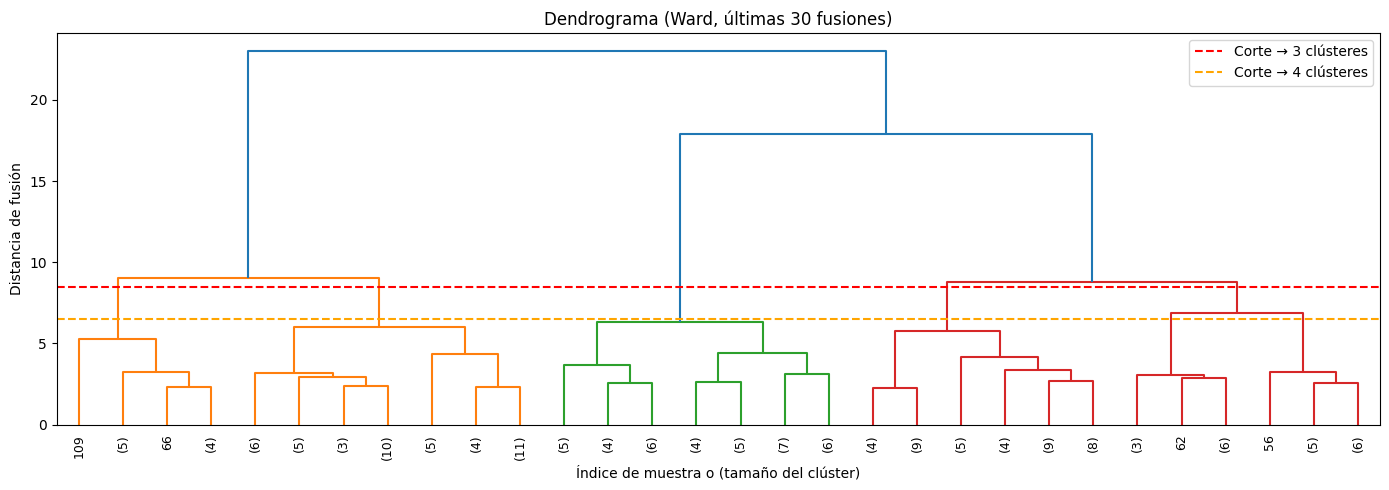

El dendrograma muestra saltos grandes al pasar de 3 a 2 clústeres,
lo que sugiere que k=3 ó k=4 son opciones razonables.


In [25]:
#Dendrograma para elegir el número de clústeres
linked = linkage(X, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9)
plt.title('Dendrograma (Ward, últimas 30 fusiones)')
plt.xlabel('Índice de muestra o (tamaño del clúster)')
plt.ylabel('Distancia de fusión')
plt.axhline(y=8.5, color='red', linestyle='--', label='Corte → 3 clústeres')
plt.axhline(y=6.5, color='orange', linestyle='--', label='Corte → 4 clústeres')
plt.legend()
plt.tight_layout()
plt.show()

print('El dendrograma muestra saltos grandes al pasar de 3 a 2 clústeres,')
print('lo que sugiere que k=3 ó k=4 son opciones razonables.')

In [26]:
#Probar k entre 3 y 5 con silhouette
print(f"{'k':>4} {'silhouette':>12}")
print('-' * 18)

best_k_hier  = None
best_sil_hier = -1

for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_k = agg.fit_predict(X)
    sil = silhouette_score(X, labels_k)
    print(f"{k:>4d} {sil:>12.4f}")
    if sil > best_sil_hier:
        best_sil_hier  = sil
        best_k_hier    = k

print(f'\nMejor k jerárquico: {best_k_hier}  (silhouette={best_sil_hier:.4f})')

   k   silhouette
------------------
   3       0.3843
   4       0.3369
   5       0.3037

Mejor k jerárquico: 3  (silhouette=0.3843)


In [27]:
#Modelo jerárquico final
hier = AgglomerativeClustering(n_clusters=best_k_hier, linkage='ward')
labels_hier = hier.fit_predict(X)

print(f'Clústeres: {best_k_hier}')
print('Distribución:', pd.Series(labels_hier).value_counts().to_dict())

Clústeres: 3
Distribución: {1: 61, 0: 55, 2: 37}


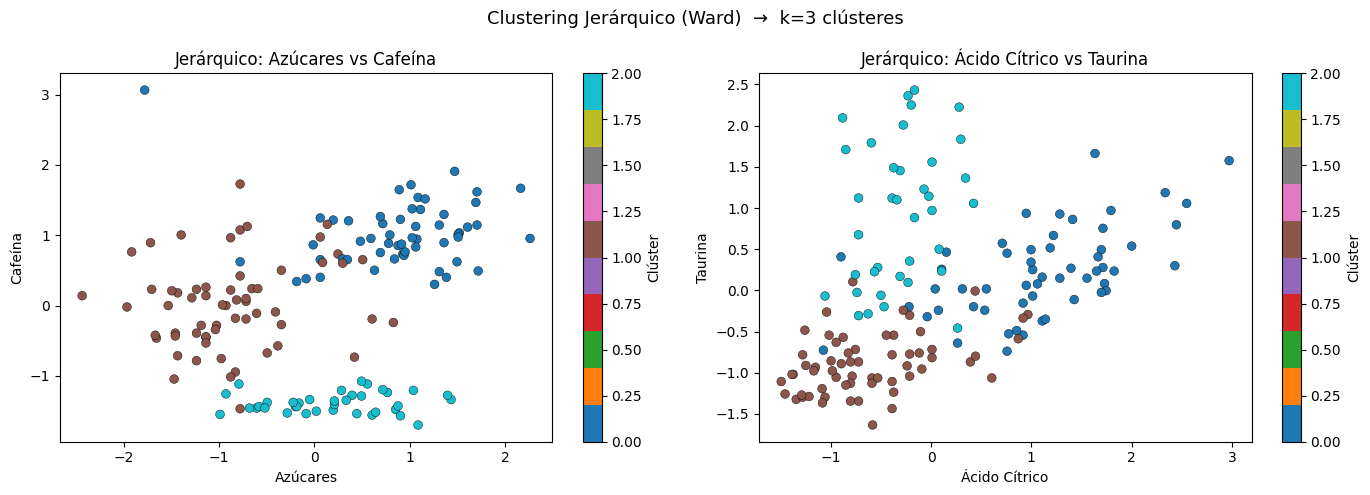

In [28]:
 #visualización jerárquico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = df.columns.tolist()

for ax, (i, j) in zip(axes, [(0, 2), (3, 4)]):
    scatter = ax.scatter(X[:, i], X[:, j], c=labels_hier,
                         cmap='tab10', s=40, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(cols[i])
    ax.set_ylabel(cols[j])
    ax.set_title(f'Jerárquico: {cols[i]} vs {cols[j]}')
    plt.colorbar(scatter, ax=ax, label='Clúster')

plt.suptitle(f'Clustering Jerárquico (Ward)  →  k={best_k_hier} clústeres', fontsize=13)
plt.tight_layout()
plt.show()

### 7. Discusión y comparación de modelos

| Algoritmo | Clústeres | Ruido | Silhouette |
|---|---|---|---|
| DBSCAN | variable | sí | calculado arriba |
| Jerárquico (Ward) | best_k_hier | no | best_sil_hier |

**¿Por qué la comparación es especulativa?**  
Porque en aprendizaje **no supervisado no hay ground-truth**: no existe un target externo que nos diga cuál segmentación es correcta. El silhouette score mide cohesión interna, pero no si los grupos tienen sentido para el negocio. Los químicos deberán interpretar los clústeres y validar si los grupos tienen sentido en términos de composición química.

**Ventajas de cada modelo:**
- *DBSCAN*: detecta clústeres de formas arbitrarias y marca automáticamente outliers (mezclas "anómalas"). No necesita especificar k de antemano.
- *Jerárquico*: no hay ruido (todas las mezclas se asignan), el dendrograma muestra la relación de similitud entre los grupos (qué segmentos se parecen más entre sí), que era algo que los químicos pedían opcionalmente.

In [29]:
#Perfil medio de cada clúster jerárquico (fácil de interpretar para los químicos)
df_hier = df.copy()
df_hier['cluster'] = labels_hier

profile = df_hier.groupby('cluster').mean().round(3)
print('Perfil medio de cada clúster (Jerárquico):')
profile

Perfil medio de cada clúster (Jerárquico):


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
cluster,,,,,
0,0.892,0.520,1.021,1.102,0.231
1,-0.873,-0.491,0.021,-0.609,-0.884
2,0.193,0.190,-1.383,-0.303,0.933


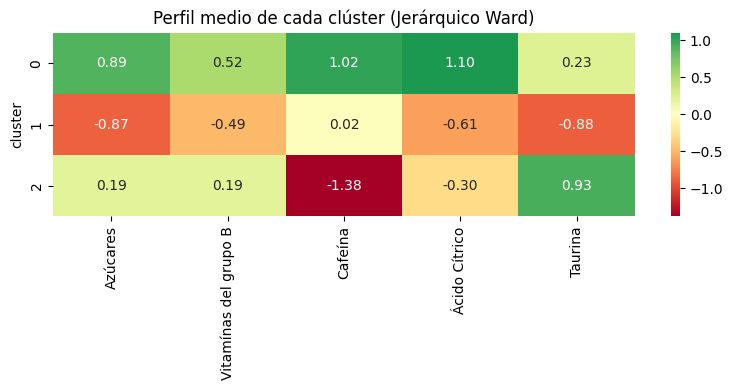

In [30]:
#Heatmap del perfil de clústeres
plt.figure(figsize=(8, 4))
sns.heatmap(profile, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Perfil medio de cada clúster (Jerárquico Ward)')
plt.tight_layout()
plt.show()

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [31]:
#Cargamos los nuevos experimentos
df_new = pd.read_csv(r'C:\Users\pc\Documents\GitHub\Marzo 2026 Ana Belén\DS-Online-Ana-Belen-Escobar\04_Machine_Learning\Sprint_13\Unidad_02_ML_No_Supervisado_Clustering_DBSCAN\03_Practica_Obligatoria\data\new_experiments.csv', sep='|')
print('Shape:', df_new.shape)
df_new

Shape: (6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [32]:
#Usar el Clustering Jerárquico porque es más sencillo de aplicar a nuevos datos:
# re-entrenar con todos los datos (originales + nuevos) ya que AgglomerativeClustering
# no tiene método predict() —es un algoritmo transductivo—.
#
# Alternativa sencilla: usar los centroides del modelo jerárquico para asignar
# cada nuevo punto al clúster más cercano.

# Calcular centroides de los clústeres
centroids = np.array([X[labels_hier == k].mean(axis=0) for k in range(best_k_hier)])

X_new = df_new.values

#Asignar cada nuevo experimento al centroide más cercano
from sklearn.metrics import pairwise_distances
dist_matrix = pairwise_distances(X_new, centroids)
new_labels = dist_matrix.argmin(axis=1)

df_new['cluster_asignado'] = new_labels
print('Nuevos experimentos con su clúster asignado:')
df_new

Nuevos experimentos con su clúster asignado:


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster_asignado
0,1.481555,0.305159,1.366128,2.239039,0.731870,0
1,0.616869,0.890014,0.583034,0.312420,-0.665332,0
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,1
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,1
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


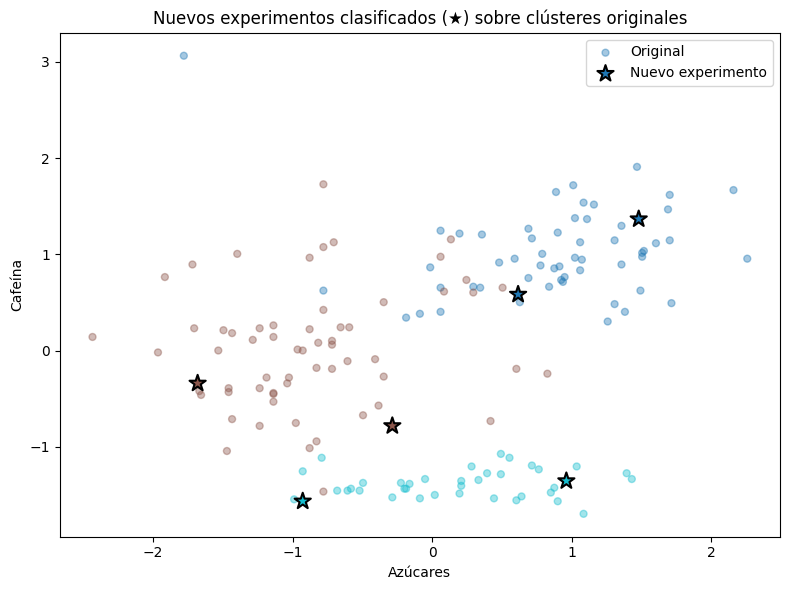

In [33]:
#Visualización de los nuevos experimentos sobre el espacio original
fig, ax = plt.subplots(figsize=(8, 6))

#Puntos originales (más pequeños y transparentes)
ax.scatter(X[:, 0], X[:, 2],
           c=labels_hier, cmap='tab10', s=25, alpha=0.4, label='Original')

#Nuevos experimentos (más grandes y con borde)
ax.scatter(X_new[:, 0], X_new[:, 2],
           c=new_labels, cmap='tab10', s=150, edgecolors='black',
           linewidths=1.5, marker='*', label='Nuevo experimento')

ax.set_xlabel(cols[0])
ax.set_ylabel(cols[2])
ax.set_title('Nuevos experimentos clasificados (★) sobre clústeres originales')
ax.legend()
plt.tight_layout()
plt.show()

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [34]:
#El fichero power_results.csv contiene 159 filas:
# 153 originales + 6 nuevos experimentos, con la etiqueta real (1, 2 o 3)
df_results = pd.read_csv(r'C:\Users\pc\Documents\GitHub\Marzo 2026 Ana Belén\DS-Online-Ana-Belen-Escobar\04_Machine_Learning\Sprint_13\Unidad_02_ML_No_Supervisado_Clustering_DBSCAN\03_Practica_Obligatoria\data\power_results.csv', sep='|')
print('Shape:', df_results.shape)
print(df_results['class'].value_counts())
df_results.head()

Shape: (159, 1)
class
2    62
1    58
3    39
Name: count, dtype: int64


,class
0,1
1,1
2,1
3,1
4,1


In [35]:
#Separar el ground truth de originales y nuevos
y_true_orig = df_results['class'].values[:153] - 1 
y_true_new  = df_results['class'].values[153:] - 1

print(f'Ground truth originales: {len(y_true_orig)} muestras')
print(f'Ground truth nuevos:     {len(y_true_new)} muestras')

Ground truth originales: 153 muestras
Ground truth nuevos:     6 muestras


In [36]:
#Adjusted Rand Index — mide similitud entre nuestra segmentación y la realidad
# (1 = perfecto, 0 = aleatorio, negativo = peor que aleatorio)

#Modelo Jerárquico vs ground truth (originales)
ari_hier = adjusted_rand_score(y_true_orig, labels_hier)
print(f'ARI Jerárquico (originales):  {ari_hier:.4f}')

#Modelo DBSCAN vs ground truth (solo puntos no-ruido)
mask_no_noise = labels_db != -1
ari_db = adjusted_rand_score(y_true_orig[mask_no_noise], labels_db[mask_no_noise])
print(f'ARI DBSCAN (sin ruido):       {ari_db:.4f}')

ARI Jerárquico (originales):  0.8160
ARI DBSCAN (sin ruido):       0.7832


In [37]:
#ARI para los nuevos experimentos (jerárquico)
ari_new = adjusted_rand_score(y_true_new, new_labels)
print(f'ARI Jerárquico (nuevos experimentos): {ari_new:.4f}')

ARI Jerárquico (nuevos experimentos): 1.0000


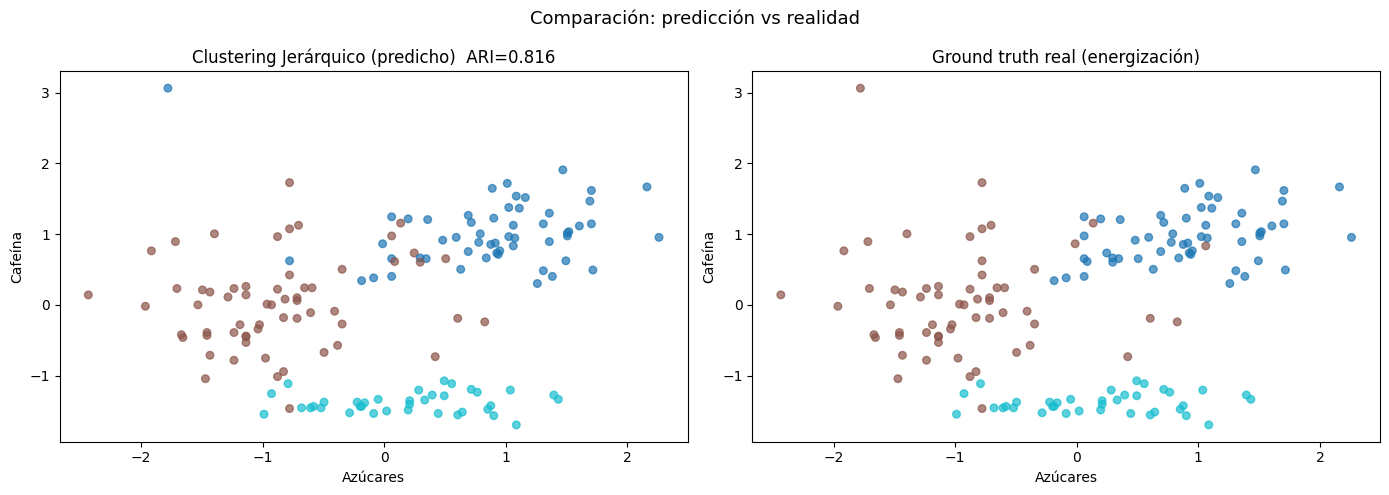

In [38]:
#Visualización: clústeres predichos vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X[:, 0], X[:, 2], c=labels_hier, cmap='tab10', s=30, alpha=0.7)
axes[0].set_title(f'Clustering Jerárquico (predicho)  ARI={ari_hier:.3f}')
axes[0].set_xlabel(cols[0])
axes[0].set_ylabel(cols[2])

axes[1].scatter(X[:, 0], X[:, 2], c=y_true_orig, cmap='tab10', s=30, alpha=0.7)
axes[1].set_title('Ground truth real (energización)')
axes[1].set_xlabel(cols[0])
axes[1].set_ylabel(cols[2])

plt.suptitle('Comparación: predicción vs realidad', fontsize=13)
plt.tight_layout()
plt.show()

### Conclusión final

- El **Adjusted Rand Index (ARI)** es la métrica apropiada para comparar una segmentación no supervisada con un ground truth externo. Varía entre -1 y 1, siendo 1 un acuerdo perfecto.
- Un ARI > 0.3 ya se considera razonable para clustering no supervisado puro.
- La diferencia entre el ARI de los datos originales y los nuevos experimentos indica si el modelo generaliza bien a nuevas mezclas.
- El clustering jerárquico tiene la ventaja adicional de que el **dendrograma** permite a los químicos entender qué segmentos son más similares entre sí, lo que facilita la interpretación de negocio.